In [10]:
import numpy as np
import rebound
import matplotlib.pyplot as plt
from celmech import Poincare, PoincareHamiltonian
#from celmech.disturbing_function import laplace_b, df_coefficient_Ctilde, evaluate_df_coefficient_dict
#import symengine as se
from tqdm import tqdm
#import heyoka as hy
#from scipy import signal
#import sympy as sp
#import time
#mport ctypes


#from hk_integrator import hk_integrate, ft, pomega_ft, get_pomega, get_ecc

In [11]:
#constants
m_sat = 2.85837e-4
m_jup = 9.945786e-4
m_c = 1

In [12]:
j_s_sim = rebound.Simulation()
j_s_sim.add(m=1, hash = "Sun")
j_s_sim.add(m=m_jup,a=5.6,e=0.06,inc = 0,Omega = 0,pomega=np.radians(13.983865),hash="Jupiter")
j_s_sim.add(m=m_sat,a=8.87,e=0.04,inc = 0, Omega = 0,pomega=np.radians(88.719425),hash="Saturn")

pvars = Poincare.from_Simulation(j_s_sim)

pham = PoincareHamiltonian(pvars)
pham.add_secular_terms(indexIn = 1, indexOut = 2, max_order = 2)
pham.add_MMR_terms(2,1, indexIn = 1, indexOut = 2, max_order = 3)

In [13]:
ast_au = [2.05,2.1,2.0,3,2.8,2.75]

sim = rebound.Simulation()

sim.add(m=1, hash = "Sun")

for i in range(6):
    rand_pomega = np.random.uniform(0, 2*np.pi)
    sim.add(m=0,a=ast_au[i],e=0,pomega =rand_pomega, inc=0)

sim.move_to_com()

sim.additional_forces = apply_planet_forces

In [14]:
sim.integrator = "whfast"
sim.dt = 0.05 * min(ast_au)**1.5 * 2 * np.pi  # auto-set from innermost asteroid

planet_states = np.zeros((2, 3))
planet_states_m = np.array([m_jup, m_sat])

def update_planet_states():
    temp_sim = pvars.to_Simulation()
    for j in range(2):
        p = temp_sim.particles[j+1]
        planet_states[j] = [p.x, p.y, p.z]

def apply_planet_forces(reb_sim_pointer):
    for i in range(1, sim.N):
        ast = sim.particles[i]
        ast_xyz = np.array([ast.x, ast.y, ast.z])
        r = planet_states - ast_xyz
        dist3 = np.sum(r**2, axis=1)**1.5
        a_vec = np.sum((planet_states_m / dist3)[:,None] * r, axis=0)
        ast.ax += a_vec[0]
        ast.ay += a_vec[1]
        ast.az += a_vec[2]

sim.additional_forces = apply_planet_forces
sim.force_is_velocity_dependent = 0

times = np.linspace(0, 1e6, int(1e4)) * 2 * np.pi
asteroid_es = [[] for _ in range(6)]

for i in tqdm(range(len(times))):
    pham.integrate(times[i])
    update_planet_states()
    sim.integrate(times[i])
    for j in range(6):
        asteroid_es[j].append(sim.particles[j+1].e)

100%|████████████████████████████████████████████████████████████████████████████| 10000/10000 [15:21<00:00, 10.86it/s]


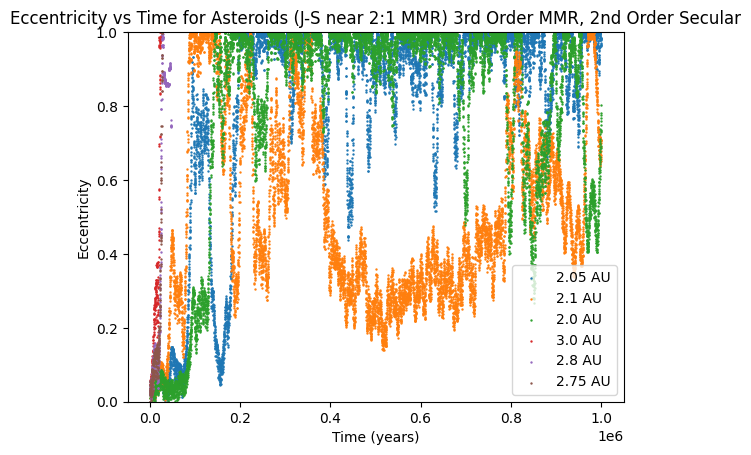

In [16]:
#graphing eccentricty vs time for the asteroids in the simulation with chaotic procession of the longitude of the perihelion
asteroid_es = np.array(asteroid_es)

ast_au = [2.05,2.1,2.0,3,2.8,2.75]
plt.title('Eccentricity vs Time for Asteroids (J-S near 2:1 MMR) 3rd Order MMR, 2nd Order Secular')
plt.scatter(times/(2*np.pi), asteroid_es[0,:],label = '2.05 AU',s = 0.5)
plt.scatter(times/(2*np.pi), asteroid_es[1,:], label = '2.1 AU', s = 0.5)
plt.scatter(times/(2*np.pi), asteroid_es[2,:], label = '2.0 AU', s = 0.5)
plt.scatter(times/(2*np.pi), asteroid_es[3,:], label = '3.0 AU', s = 0.5)
plt.scatter(times/(2*np.pi), asteroid_es[4,:], label = '2.8 AU', s = 0.5)
plt.scatter(times/(2*np.pi), asteroid_es[5,:], label = '2.75 AU', s = 0.5)
plt.xlabel('Time (years)')
plt.ylabel('Eccentricity')
plt.legend()
plt.ylim(top=1)
plt.ylim(bottom=0)
plt.show()

100%|███████████████████████████████████████████████████████████████████████████| 10000/10000 [00:21<00:00, 456.54it/s]


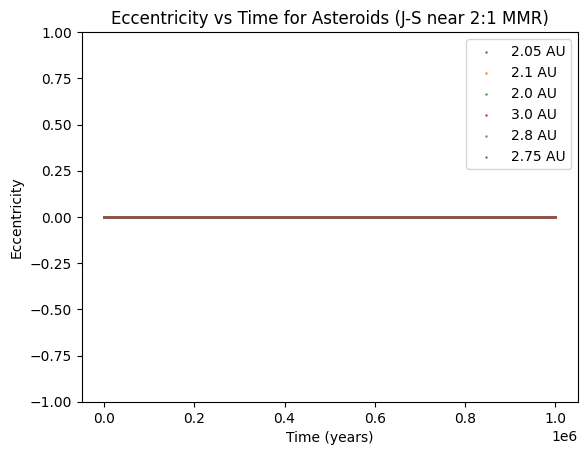

In [44]:
ecc = [0.05,0.1,0.06,0.03,0.05,0.055]
ast_au = [2.05,2.1,2.0,3,2.8,2.75]

sim = rebound.Simulation()

sim.add(m=1, hash = "Sun")

for i in range(6):
    rand_pomega = np.random.uniform(0, 2*np.pi)
    sim.add(m=0,a=ast_au[i],e=0,pomega =rand_pomega, inc=0)

sim.move_to_com()

#sim.additional_forces = apply_planet_forces

sim.integrator = "whfast"
sim.dt = 0.05 * min(ast_au)**1.5 * 2 * np.pi  # auto-set from innermost asteroid

planet_states = np.zeros((2, 3))
planet_states_m = np.array([m_jup, m_sat])

def update_planet_states():
    temp_sim = pvars.to_Simulation()
    for j in range(2):
        p = temp_sim.particles[j+1]
        planet_states[j] = [p.x, p.y, p.z]

def apply_planet_forces(reb_sim_pointer):
    for i in range(1, sim.N):
        ast = sim.particles[i]
        ast_xyz = np.array([ast.x, ast.y, ast.z])
        r = planet_states - ast_xyz
        dist3 = np.sum(r**2, axis=1)**1.5
        a_vec = np.sum((planet_states_m / dist3)[:,None] * r, axis=0)
        ast.ax += a_vec[0]
        ast.ay += a_vec[1]
        ast.az += a_vec[2]

sim.additional_forces = apply_planet_forces
sim.force_is_velocity_dependent = 0

times = np.linspace(0, 1e6, int(1e4)) * 2 * np.pi
asteroid_es = [[] for _ in range(6)]

for i in tqdm(range(len(times))):
    pham.integrate(times[i])
    #update_planet_states()
    #sim.integrate(times[i])
    for j in range(6):
        asteroid_es[j].append(sim.particles[j+1].e)

asteroid_es = np.array(asteroid_es)

ast_au = [2.0,2.5,3,1.5,3.5,1.25]
plt.title('Eccentricity vs Time for Asteroids (J-S near 2:1 MMR)')
plt.scatter(times/(2*np.pi), asteroid_es[0,:],label = '2.05 AU',s = 0.5)
plt.scatter(times/(2*np.pi), asteroid_es[1,:], label = '2.1 AU', s = 0.5)
plt.scatter(times/(2*np.pi), asteroid_es[2,:], label = '2.0 AU', s = 0.5)
plt.scatter(times/(2*np.pi), asteroid_es[3,:], label = '3.0 AU', s = 0.5)
plt.scatter(times/(2*np.pi), asteroid_es[4,:], label = '2.8 AU', s = 0.5)
plt.scatter(times/(2*np.pi), asteroid_es[5,:], label = '2.75 AU', s = 0.5)
plt.xlabel('Time (years)')
plt.ylabel('Eccentricity')
plt.legend()
plt.ylim(top=1)
plt.ylim(bottom=-1)
plt.show()